# **PHISHING EMAILS DETECTION MODEL**


### **MAIN GOAL**
- To train model that can distinguish between a legitimate email and a phishing email and experminet with fine-tuning


### **DATASET USED**
- zefang-liu/phishing-email-dataset from Hugging Face => https://huggingface.co/datasets/zefang-liu/phishing-email-dataset


### **MODELS USED**
1. **BERT (bert-base-uncased)** - is designed to understand the context of words in a sentence by looking at both directions (left and right), which makes it very effective for tasks like:
    - Text classification (e.g., spam vs. not spam, phishing detection)
    - Question answering
    - Sentiment analysis

2. **CySecBERT** - is a specialized version of the BERT model that is focused on cybersecurity-related text.
    - **Purpose**: Built to better understand cybersecurity language, such as phishing emails, malware descriptions, attack reports, and logs.
    - **Training**: Fine-tuned on cybersecurity datasets, so it learns domain-specific terms and patterns.
    - **Use cases**:
        - Phishing detection
        - Malware classification
        - Security log analysis


### **METRICS USED**
1. F1-score
2. Precision
3. Recall
4. Accuracy
5. ROC-AUC

### **WORKFLOW**
1. Load a phishing dataset from the Hugging Face Hub, check main characteristics, clean it and prepare text inputs for classification using load_dataset().
2. Implement a baseline bert-base-uncased model and compare it with the domain-specific CySecBERT model from Hugging Face.
3. Fine-tune the model for binary text classification (phishing vs. legitimate).
4. Evaluate using F1-score, precision, recall, accuracy, and ROC-AUC.
5. Perform error analysis to see where the model makes mistakes and why.
6. (Optional) Add explainability using SHAP or LIME to identify key phrases influencing predictions.

In [14]:
import pandas as pd
import numpy as np
from datasets import load_dataset

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = load_dataset('zefang-liu/phishing-email-dataset', split="train")
#df = df.to_pandas()

In [3]:
print(df)


Dataset({
    features: ['Unnamed: 0', 'Email Text', 'Email Type'],
    num_rows: 18650
})


In [4]:
for i in range(10):
    print(df[i])

{'Unnamed: 0': 0, 'Email Text': 're : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson \'s observations on us use of \'s on \' but not \'d aughter \' as a vocative are very thought-provoking , but i am not sure that it is fair to attribute this to " sons " being " treated like senior relatives " . for one thing , we do n\'t normally use \' brother \' in this way any more than we do \'d aughter \' , and it is hard to imagine a natural class comprising senior relatives and \'s on \' but excluding \' brother \' . for another , there seem to me to be differences here . if i am not imagining a distinction that is not there , it seems to me that the senior relative terms are used in a wider variety of contexts , e . g . , calling out from a distance to get someone \'s attention , and hence at the beginning of an utterance , whereas \'s on \' seems more natural in utterances like \' yes , son \' , \' hand me that , son \' than in ones like \' son ! \' or \' son , help 

In [5]:
df = df.to_pandas()

In [6]:
df.head()

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  int64 
 1   Email Text  18634 non-null  object
 2   Email Type  18650 non-null  object
dtypes: int64(1), object(2)
memory usage: 437.2+ KB


In [8]:
df.shape

(18650, 3)

In [9]:
#Check for missing values
df.isnull().sum()

Unnamed: 0     0
Email Text    16
Email Type     0
dtype: int64

In [10]:
#Check for duplictes
df.duplicated().sum()

np.int64(0)

In [11]:
#Remove rows with missing values
df = df.dropna()

#Remove Unnamed: 0 column
df = df.drop(columns='Unnamed: 0')

#Rename columns
df.columns = ['text', 'label']

In [12]:
df.head()

,text,label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email


C:\Users\MSI\AppData\Local\Temp\ipykernel_18704\1974444293.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='tab10')


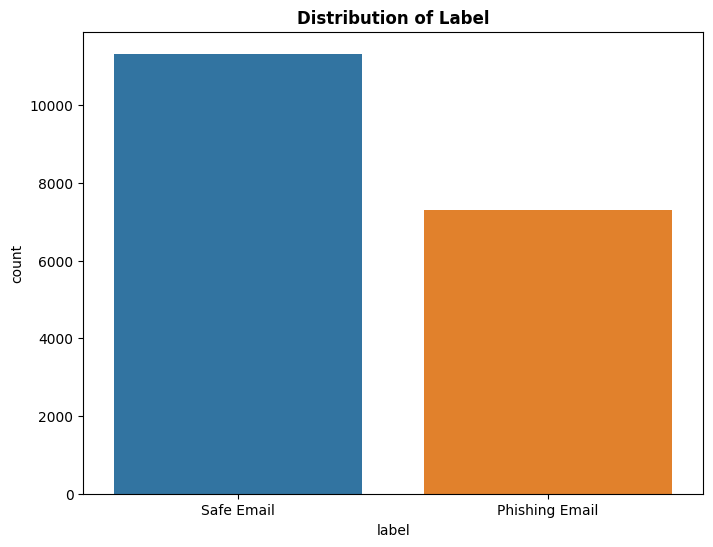

In [19]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='label', palette='tab10')
plt.title('Distribution of Label', fontweight='bold')
plt.show()